<a href="https://colab.research.google.com/github/saliou2/7168871-apprenez-les-bases-du-langage-python/blob/main/traitement_de_donn%C3%A9es_pyspark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

Importation des modules

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import count, desc, col, max, struct
import matplotlib.pyplot as plts

Création d'une session spark

In [2]:
spark = SparkSession.builder.appName("spark_app").getOrCreate()

Téléchargement des jeu de données

Importation du fichier listening.csv

In [4]:
listening_csv_path = "/content/drive/MyDrive/Colab Notebooks/jeu_de_donnees/listenings.csv"
listening_df = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(listening_csv_path)


In [5]:
listening_df.show()

+-----------+-------------+--------------------+---------------+--------------------+
|    user_id|         date|               track|         artist|               album|
+-----------+-------------+--------------------+---------------+--------------------+
|000Silenced|1299680100000|           Price Tag|       Jessie J|         Who You Are|
|000Silenced|1299679920000|Price Tag (Acoust...|       Jessie J|           Price Tag|
|000Silenced|1299679440000|Be Mine! (Ballad ...|          Robyn|            Be Mine!|
|000Silenced|1299679200000|            Acapella|          Kelis|            Acapella|
|000Silenced|1299675660000|   I'm Not Invisible|      The Tease|   I'm Not Invisible|
|000Silenced|1297511400000|Bounce (Feat NORE...|       MSTRKRFT|         Fist of God|
|000Silenced|1294498440000|Don't Stop The Mu...|        Rihanna|Addicted 2 Bassli...|
|000Silenced|1292438340000|               ObZen|      Meshuggah|               ObZen|
|000Silenced|1292437740000|   Yama's Messengers|      

Nettoyage


In [7]:
listening_df = listening_df.na.drop()

In [8]:
listening_df.show()

+-----------+-------------+--------------------+---------------+--------------------+
|    user_id|         date|               track|         artist|               album|
+-----------+-------------+--------------------+---------------+--------------------+
|000Silenced|1299680100000|           Price Tag|       Jessie J|         Who You Are|
|000Silenced|1299679920000|Price Tag (Acoust...|       Jessie J|           Price Tag|
|000Silenced|1299679440000|Be Mine! (Ballad ...|          Robyn|            Be Mine!|
|000Silenced|1299679200000|            Acapella|          Kelis|            Acapella|
|000Silenced|1299675660000|   I'm Not Invisible|      The Tease|   I'm Not Invisible|
|000Silenced|1297511400000|Bounce (Feat NORE...|       MSTRKRFT|         Fist of God|
|000Silenced|1294498440000|Don't Stop The Mu...|        Rihanna|Addicted 2 Bassli...|
|000Silenced|1292438340000|               ObZen|      Meshuggah|               ObZen|
|000Silenced|1292437740000|   Yama's Messengers|      

Structure

Schéma de nos données

In [9]:
listening_df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- date: long (nullable = true)
 |-- track: string (nullable = true)
 |-- artist: string (nullable = true)
 |-- album: string (nullable = true)



taille du dataframe

In [10]:
shape = (listening_df.count(), len(listening_df.columns))
print(shape)

(13758905, 5)


Requete pour extraire des informations utiles de nos données Spark

Requete 0: Afficher deux colonnes: track et artist

>



In [11]:
q0 = listening_df.select("track", "artist")
q0.show()

+--------------------+---------------+
|               track|         artist|
+--------------------+---------------+
|           Price Tag|       Jessie J|
|Price Tag (Acoust...|       Jessie J|
|Be Mine! (Ballad ...|          Robyn|
|            Acapella|          Kelis|
|   I'm Not Invisible|      The Tease|
|Bounce (Feat NORE...|       MSTRKRFT|
|Don't Stop The Mu...|        Rihanna|
|               ObZen|      Meshuggah|
|   Yama's Messengers|         Gojira|
|On the Brink of E...|   Napalm Death|
|On the Brink of E...|   Napalm Death|
|        In Deference|   Napalm Death|
|      Post(?)organic|    Decapitated|
|        Mind Feeders|   Dom & Roland|
|Necrosadistic War...|Cannibal Corpse|
|     Dance All Night|   Dom & Roland|
|          Late Night|   Dom & Roland|
|          Freak Seen|   Dom & Roland|
|Paradrenasite (Hi...|   Dom & Roland|
|               Rhino|   Dom & Roland|
+--------------------+---------------+
only showing top 20 rows


Requete 1: Rechercher des enregistrement où les utilisateurs ont écoutés Rihanna

In [12]:
q1 = listening_df.select('*').filter(listening_df.artist == "Rihanna")
q1.show()

+-----------+-------------+--------------------+-------+--------------------+
|    user_id|         date|               track| artist|               album|
+-----------+-------------+--------------------+-------+--------------------+
|000Silenced|1294498440000|Don't Stop The Mu...|Rihanna|Addicted 2 Bassli...|
|000Silenced|1285438440000|           Disturbia|Rihanna|Good Girl Gone Ba...|
|00williamsl|1361485800000|   Hatin On The Club|Rihanna|              Random|
|00williamsl|1361485800000|   Hatin On The Club|Rihanna|              Random|
|00williamsl|1361048640000|         Complicated|Rihanna|                Loud|
|00williamsl|1360439280000|What's My Name (f...|Rihanna|                Loud|
|00williamsl|1360434480000|Kanye West feat R...|Rihanna|                Loud|
|    0502008|1440985800000|Only Girl (In the...|Rihanna|                Loud|
|      0rdos|1319599320000|Pon De Replay (Re...|Rihanna|    Music of the Sun|
|      0rdos|1319599080000|          Now I Know|Rihanna|    Musi

Afficher les 10 meilleurs fan de Rihanna

In [13]:
q2 = listening_df.select('user_id', 'artist').filter(listening_df.artist == "Rihanna").groupby('user_id').agg(count('user_id').alias('count')).orderBy(desc('count')).limit(10)
q2.show()

+---------------+-----+
|        user_id|count|
+---------------+-----+
|        thiessu|  179|
|    eyessetkyle|  166|
|           adxx|  164|
|missnumberthree|  156|
|helloiamnatalie|  128|
|          nmjnb|  124|
|        AndyyyA|  123|
|     BIGBANG186|  121|
|     mixedvibes|  120|
|       AndyKitt|  115|
+---------------+-----+



Requete 3:Afficher les 10 track les plus populaire

In [14]:
q3 = listening_df.select('artist','track').groupby('artist','track').agg(count('*').alias('count')).orderBy(desc('count')).limit(10)
q3.show()

+--------------+----------------+-----+
|        artist|           track|count|
+--------------+----------------+-----+
| Justin Bieber|           Sorry| 3381|
|Arctic Monkeys|Do I Wanna Know?| 2865|
|      Bon Iver|     Skinny Love| 2836|
|          Zayn|      PILLOWTALK| 2701|
|   The Killers|   Mr Brightside| 2690|
|       Rihanna|            Work| 2646|
|      Bastille|         Pompeii| 2606|
|Mumford & Sons| Little Lion Man| 2520|
|Mumford & Sons|        The Cave| 2485|
| Justin Bieber|   Love Yourself| 2481|
+--------------+----------------+-----+



Requete 4:Afficher les 10 track les plus populaire de Rihanna

In [16]:
q4 = listening_df.select('artist','track').filter(listening_df.artist == "Rihanna").groupby('artist','track').agg(count('*').alias('count')).orderBy(desc('count')).limit(10)
q4.show()

+-------+--------------------+-----+
| artist|               track|count|
+-------+--------------------+-----+
|Rihanna|                Work| 2646|
|Rihanna|Only Girl (In the...| 1749|
|Rihanna|We Found Love (fe...| 1575|
|Rihanna|                 S&M| 1307|
|Rihanna|            Rude Boy| 1303|
|Rihanna|            Diamonds| 1224|
|Rihanna|      Kiss it Better|  945|
|Rihanna| Where Have You Been|  844|
|Rihanna|Cheers (Drink to ...|  697|
|Rihanna|           Needed Me|  679|
+-------+--------------------+-----+



Requete 5:Afficher les 10 albums les plus populaire

In [17]:
q5 = listening_df.select('artist','album').groupby('artist','album').agg(count('*').alias('count')).orderBy(desc('count')).limit(10)
q5.show()

+--------------------+--------------------+-----+
|              artist|               album|count|
+--------------------+--------------------+-----+
|          Kanye West|   The Life Of Pablo|22310|
|              The xx|                  xx|14195|
|      Arctic Monkeys|                  AM|14090|
|               alt-J|     An Awesome Wave|13635|
|      Mumford & Sons|        Sigh No More|13543|
|      Arctic Monkeys|Whatever People S...|12731|
|            Bon Iver|            For Emma|11994|
|              Grimes|          Art Angels|11655|
|Florence + the Ma...|               Lungs|11362|
|               Adele|                  21|11215|
+--------------------+--------------------+-----+



Importation du fichier genre.csv

In [18]:
genre_csv_path = "/content/drive/MyDrive/Colab Notebooks/jeu_de_donnees/genre.csv"
genre_df = spark.read.format("csv").option("inferScheme", "true").option("header", "true").load(genre_csv_path)
genre_df.show()

+--------------------+-----+
|              artist|genre|
+--------------------+-----+
|                Muse| rock|
|             Nirvana| rock|
|            Bon Jovi| rock|
|          The Police| rock|
|                Kiss| rock|
|       Guns N' Roses| rock|
|         Rusted Root| rock|
|Katrina and the W...|  pop|
|         The Beatles| rock|
|        Hall & Oates|  pop|
|        Otis Redding| soul|
|         Marvin Gaye| soul|
|     The Cranberries| rock|
|            Survivor| rock|
|       Fleetwood Mac|blues|
|           Radiohead| rock|
|                Toto| rock|
|                  U2| rock|
|Creedence Clearwa...| rock|
|                 REM| rock|
+--------------------+-----+
only showing top 20 rows


Joindre 2 dataframes et le préparer pour des requete plus avancées

In [19]:
data = listening_df.join(genre_df, how = 'inner', on = ['artist'])
data.show()

+------------+-----------+-------------+--------------------+--------------------+--------------------+
|      artist|    user_id|         date|               track|               album|               genre|
+------------+-----------+-------------+--------------------+--------------------+--------------------+
|    Jessie J|000Silenced|1299680100000|           Price Tag|         Who You Are| Ariana Grande & ...|
|    Jessie J|000Silenced|1299680100000|           Price Tag|         Who You Are| Jhene Aiko & Rixton|
|    Jessie J|000Silenced|1299680100000|           Price Tag|         Who You Are| Nicki Minaj & Ar...|
|    Jessie J|000Silenced|1299680100000|           Price Tag|         Who You Are|                 pop|
|    Jessie J|000Silenced|1299679920000|Price Tag (Acoust...|           Price Tag| Ariana Grande & ...|
|    Jessie J|000Silenced|1299679920000|Price Tag (Acoust...|           Price Tag| Jhene Aiko & Rixton|
|    Jessie J|000Silenced|1299679920000|Price Tag (Acoust...|   

Requete 6: Afficher les 10 utilisateurs les plus fan de la musique pop

In [20]:
q6 = data.select('user_id','genre').filter(data.genre == "pop").groupby('user_id').agg(count('*').alias('count')).orderBy(desc('count')).limit(10)
q6.show()

+---------------+-----+
|        user_id|count|
+---------------+-----+
|        01Green|  496|
|      momousagi|  400|
|          mrpsb|  400|
|   BlueKnockOut|  378|
|    musicboy80s|  376|
|  incultojurgis|  374|
| ElektricOrchid|  370|
|foreign_fanatic|  350|
|   Kevin_Soutar|  346|
|  landrover2171|  301|
+---------------+-----+



Requete 7: Afficher les 10 genre les plus populaire

In [21]:
q7 = data.select('genre').groupby('genre').agg(count('*').alias('count')).orderBy(desc('count')).limit(10)
q7.show()

+----------+-------+
|     genre|  count|
+----------+-------+
|      rock|2691934|
|       pop|1544747|
|electronic| 551509|
|   hip hop| 532984|
|      folk| 438174|
|indie rock| 431439|
|      punk| 380915|
|       r&b| 344101|
|     metal| 208107|
|     indie| 206726|
+----------+-------+



Requete 8: Afficher le genre préféré de chaque utilisateur ( la fonction struck)

In [22]:
q8_1 = data.select('user_id','genre').groupby('user_id','genre').agg(count('*').alias('count')).orderBy('user_id','count')
q8_1.show()

+-------+--------------------+-----+
|user_id|               genre|count|
+-------+--------------------+-----+
| --Seph| Boston Pops Orch...|    1|
| --Seph|                fado|    1|
| --Seph|       Sara Mingardo|    1|
| --Seph|    Sir James Galway|    1|
| --Seph| Tamás Vásáry & Y...|    1|
| --Seph|        instrumental|    1|
| --Seph| Orchestra of Wel...|    1|
| --Seph|              trance|    1|
| --Seph|               dance|    1|
| --Seph|             new age|    1|
| --Seph|                soul|    1|
| --Seph| Sara Mingardo & ...|    1|
| --Seph| The Ambrosian Si...|    1|
| --Seph|     Hilko Schomerus|    1|
| --Seph|   progressive house|    1|
| --Seph|             Rihanna|    1|
| --Seph|          electropop|    1|
| --Seph| Ne-Yo & Nicky Ro...|    1|
| --Seph|           indie pop|    1|
| --Seph|          ninja tune|    1|
+-------+--------------------+-----+
only showing top 20 rows


In [23]:
q8_2 = q8_1.groupby('user_id').agg(max(struct(col('count'), col('genre'))).alias('max')).select(col('user_id'), col('max.genre'))
q8_2.show()

+---------------+-----------+
|        user_id|      genre|
+---------------+-----------+
|      --Shinn--|       rock|
|       --ollz--|       rock|
|     -Amnesiac-|      metal|
|         -Bish-|       rock|
|        -Danni-|       rock|
|          -DeWp|    hip hop|
|      -Faction-|       rock|
|-February-Star-|       rock|
|        -Gemma-|british pop|
|   -Gingergirl-|        pop|
|        -Hazel-|   synthpop|
|        -Heiko-| electronic|
|         -Katie|      lo-fi|
|      -Krystal-|       rock|
|         -Mark-| indie rock|
|       -Mullet-|  metalcore|
|          -Robs|       rock|
| -SleepingStar-|black metal|
|      -Stifler-|       rock|
|  -Toxic-Waste-|  aggrotech|
+---------------+-----------+
only showing top 20 rows


Requete 9: recherchons le nombre d'artistes  dans les catégories rock, pop, metal et hip hop

In [26]:
q9 = genre_df.select('genre').filter((col('genre')=='pop') | (col('genre')=='rock') | (col('genre')=='metal') | (col('genre')=='hip hop')).groupby('genre').agg(count('*').alias('count')).orderBy('count')
q9.show()

+-------+-----+
|  genre|count|
+-------+-----+
|  metal| 1854|
|hip hop| 4288|
|    pop| 6960|
|   rock| 9066|
+-------+-----+



Visualisation de nos requetes via Matplotlib

In [27]:
# Pour visualiser ce résultat avec matplotlib , nous créons 2 listes pour chacune de ses colonnnes comme suit:

In [28]:
q9_list = q9.collect()
q9_list

[Row(genre='metal', count=1854),
 Row(genre='hip hop', count=4288),
 Row(genre='pop', count=6960),
 Row(genre='rock', count=9066)]

In [29]:
labels = [row['genre'] for row in q9_list]
counts = [row['count'] for row in q9_list]

In [30]:
print(labels)
print(counts)

['metal', 'hip hop', 'pop', 'rock']
[1854, 4288, 6960, 9066]


Visualisation de ces 2 listes en utlisant le diagramme en bande

<BarContainer object of 4 artists>

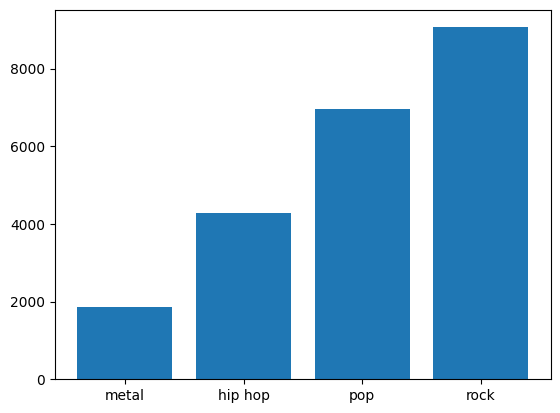

In [31]:
plts.bar(labels, counts)
